In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA, TruncatedSVD

# Working with Text Exercise
## Information retrieval, preprocessing, and feature extraction

In this lab, you'll be looking at and exploring European news from the AG News dataset, located [here](https://huggingface.co/datasets/sh0416/ag_news).

For most of this exercise, you can safely ignore the `test.jsonl` file. However, if you know what a train / test split is and how to use it - feel free to do so! :)

### Problem 1. Read the dataset
The dataset has, at first glance, a slightly weird file format and structure. Find a way to read and explore it.

Make some initial analysis steps. Show representative examples, document-length statistics, and any obvious differences between titles and descriptions.

Write a short note on what you expect to be easy, what you expect to be difficult, and what kinds of mistakes a simple text pipeline might make.

In [3]:
pd.read_json('data/train.jsonl', lines=True)

,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
...,...,...,...
119995,1,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...
119996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...
119997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...
119998,2,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...


In [4]:
ag_news = pd.read_json('data/train.jsonl', lines=True)

### Problem 2. Title and description
Treat the title, the description, and the concatenation of both as three different text sources. Compare them statistically and qualitatively.

Which seems more informative? Which seems noisier? Which seems more likely to help a simple classifier?

Some representation stats you might want to include are:
* average token counts
* vocabulary size
* most frequent terms
* whether titles contain stronger topic indicators
* \* duplicate-like titles (this is a lot harder at this stage)

In [6]:
ag_news.label.value_counts().sort_index()

label
1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64

In [7]:
ag_news.title.str.len()

0         49
1         51
2         47
3         60
4         73
          ..
119995    50
119996    33
119997    31
119998    17
119999    28
Name: title, Length: 120000, dtype: int64

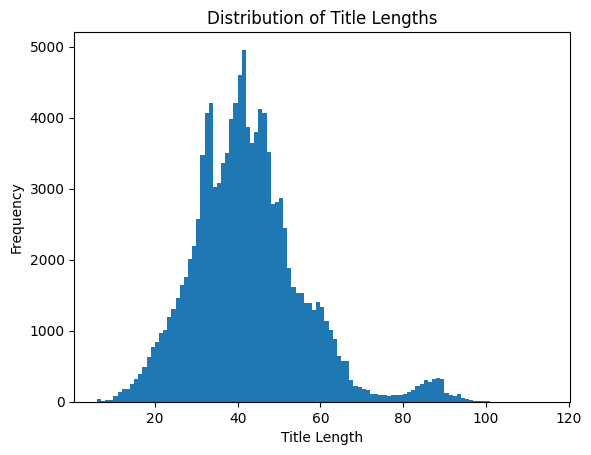

In [8]:
plt.hist(ag_news.title.str.len(), bins='fd')
plt.xlabel('Title Length')
plt.ylabel('Frequency')
plt.title('Distribution of Title Lengths')
plt.show()

In [9]:
ag_news[ag_news.title.str.len() > 80].sample(20).title

48454     France, Spain swoop on ETA suspects, arrest se...
97923     US forces find two more bodies near Mosul; mil...
86305     Equestrianism: O #39;Connor to lose gold as dr...
78736     Stock market crash course: what goes down does...
77128     Andrew Kantor: CyberSpeak - Sinclair is the la...
10933     Yukos accounting division raided; Russian offi...
17045     Report details ways it says Black, Radler took...
61485     Judge approves US Airways financing deal, dela...
113674    Action film star who lost Philippines' preside...
22297     Hurricane Ivan ravages Grenada, killing 15 and...
53714     Woman mauled by grizzly in southern Alberta, e...
46611     Syria condemns assassination attempt against f...
74903     Newfoundland premier invokes historic grievanc...
40140     Todt on the race, Rubens #39; victory, strateg...
55215     India,Sports ; Cricket: Ind-Aus test match day...
81643     Militants used grenade attacks to lure Black W...
39691     Malaysian woman reclaims  quot

In [10]:
ag_news[ag_news.title.str.len() > 80].sample(20, random_state=42).title.values

<StringArray>
[          'Thai woman confirmed with bird flu as fears over human-to-human &lt;b&gt;...&lt;/b&gt;',
        'Indonesia #39;s Yudhoyono hails victory, vows to tackle corruption &lt;b&gt;...&lt;/b&gt;',
               'Entertainment part of Paralympics closing ceremony canceled &lt;b&gt;...&lt;/b&gt;',
        'Astronomers discover first Neptune-sized planets outside our solar &lt;b&gt;...&lt;/b&gt;',
              'No decision taken by Musharraf on army chief post: Pakistani &lt;b&gt;...&lt;/b&gt;',
                'GEORGIA TECH 99, MICHIGAN 68: Harris, Horton off-kilter in &lt;b&gt;...&lt;/b&gt;',
            'Oil prices drop sharply to \$42US per barrel in spite of Iraqi &lt;b&gt;...&lt;/b&gt;',
         'Serena, Sharapova Avoid the Choke to Advance to WTA Championships &lt;b&gt;...&lt;/b&gt;',
          'US forces find two more bodies near Mosul; militant group claims &lt;b&gt;...&lt;/b&gt;',
   'Former Alta city councillor gets conditional sentence for fabricating sta

In [11]:
ag_news[
    (ag_news.title.str.len() >= 35) &
    (ag_news.title.str.len() <= 45)
].sample(20, random_state=42).title.values

<StringArray>
[    'Thailand confirms second case of bird flu',
       'Staples Profit Up; Sees 4th Qtr in Line',
   'Bush's Nephew Rips Armed Border Guards (AP)',
      'Calif. Democrats File FCC Complaint (AP)',
         'Iomega backs away from DCT, cuts jobs',
     'Now piracy curse strikes GTA: San Andreas',
        'Anwar makes  #39;amazing #39; recovery',
      'Israeli cabinet to decide on Sharon plan',
       'Premiership: Ban Diouf, for a long time',
 'India, Pakistan To Discuss Gas Pipeline Issue',
     'New Wi-Fi Nearly Doubles Speed (PC World)',
     'A Low-Key Olympic Return for Marion Jones',
        'Treasuries Rise on Greenspan's Remarks',
     'Bush Finished Campaign With Millions (AP)',
          'IBM, Borland upgrade developer tools',
     'NASA spacecraft design pioneer Faget dies',
   'Sudan slams Powell's 'genocide' declaration',
         'Consumers Tighten Borrowing in August',
           'Unilever Sales Fall 4 Percent in 3Q',
  'Online fraud: We got law, but no 

In [12]:
len(ag_news.loc[97179].title)

86

In [13]:
ag_news[ag_news.title.str.len() < 15].sample(20, random_state=42).title.values

<StringArray>
[   'FOUND MONEY',   'The War Room',   'D. Miller, C',  'Familiar Foes',
 'Hall of a time', 'They have bond',    'Music Notes',   'Goodbye Gaza',
  'Kobe Rebounds',   'SPORTS ON TV',  'Harriet Rubin',   'Catie Whelan',
   'Transactions', 'Rog still best', 'David Nicklaus', 'Tehran defiant',
     'Dell  AMD?',    'NL notables',       'Sun burn',        'YES!!! ']
Length: 20, dtype: str

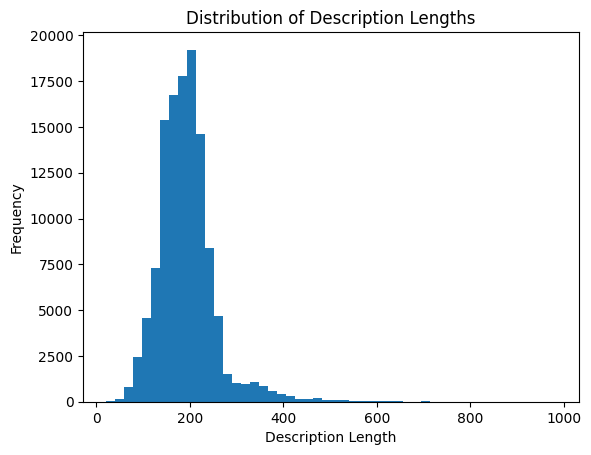

In [15]:
plt.hist(ag_news.description.str.len(), bins=50)
plt.xlabel('Description Length')
plt.ylabel('Frequency')
plt.title('Distribution of Description Lengths')
plt.show()

In [16]:
ag_news[ag_news.description.str.len() < 200].sample(20, random_state=42).description.values

<StringArray>
[                      'Some German bus commuters should soon try using their mobile phones as electronic wallets when a new trial of the technology called Near Field Communications gets underway.',
                                'The PlayStation Portable, or PSP, goes on sale in Japan on December 12th. Prices for the United States and Europe are still undecided, although overseas sales are ',
    'AP - U.S. warplanes, tanks and artillery units attacked the insurgent stronghold of Fallujah on Saturday, killing at least eight people and wounding 15, hospital officials and witnesses said.',
                         'The Philadelphia Phillies made a move to bolster their starting rotation by signing free agent righthander Jon Lieber to a three-year, \$21 million contract on Wednesday.',
                   'The New Orleans Hornets #39; Jamal Mashburn will sit out all of next season on the injured list to ready himself for a final comeback attempt in 2005-06, NBA sources told

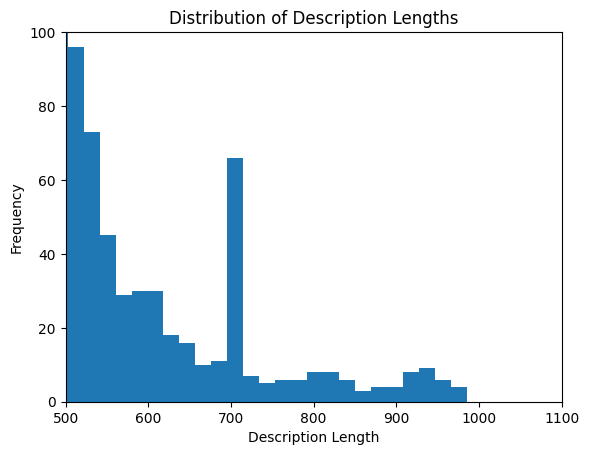

In [18]:
plt.hist(ag_news.description.str.len(), bins=50)
plt.xlim(500, 1100)
plt.ylim(0, 100)
plt.xlabel('Description Length')
plt.ylabel('Frequency')
plt.title('Distribution of Description Lengths')
plt.show()

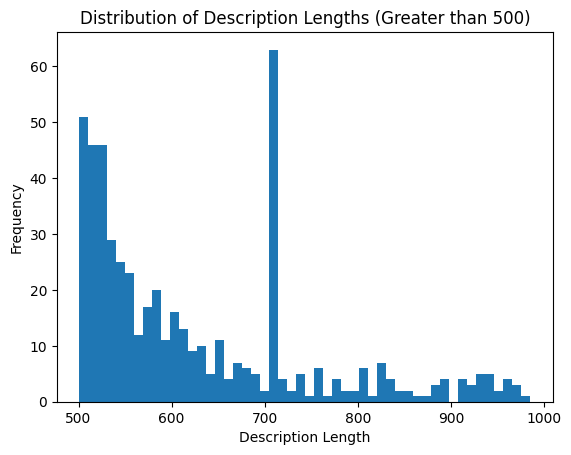

In [19]:
description_lengths = ag_news.description.str.len()
plt.hist(description_lengths[description_lengths > 500], bins=50)
plt.xlabel('Description Length')
plt.ylabel('Frequency')
plt.title('Distribution of Description Lengths (Greater than 500)')
plt.show()

In [23]:
title_counter = CountVectorizer()
title_counts = title_counter.fit_transform(ag_news.title)

description_counter = CountVectorizer()
description_counts = description_counter.fit_transform(ag_news.description)

In [24]:
len(title_counter.vocabulary_)

33495

In [25]:
len(description_counter.vocabulary_)

60741

In [27]:
title_counter.vocabulary_.keys() 

dict_keys(['wall', 'st', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'carlyle', 'looks', 'toward', 'commercial', 'aerospace', 'oil', 'and', 'economy', 'cloud', 'stocks', 'outlook', 'iraq', 'halts', 'exports', 'from', 'main', 'southern', 'pipeline', 'prices', 'soar', 'to', 'all', 'time', 'record', 'posing', 'new', 'menace', 'us', 'afp', 'end', 'up', 'but', 'near', 'year', 'lows', 'money', 'funds', 'fell', 'in', 'latest', 'week', 'ap', 'fed', 'minutes', 'show', 'dissent', 'over', 'inflation', 'usatoday', 'com', 'safety', 'net', 'forbes', 'no', 'need', 'for', 'opec', 'pump', 'more', 'iran', 'gov', 'non', 'nations', 'should', 'output', 'purnomo', 'google', 'ipo', 'auction', 'off', 'rocky', 'start', 'dollar', 'falls', 'broadly', 'on', 'trade', 'gap', 'rescuing', 'an', 'old', 'saver', 'kids', 'rule', 'school', 'down', 'market', 'head', 'value', 'deficit', 'swells', 'june', 'shell', 'could', 'be', 'target', 'total', 'faces', 'playboy', 'slip', 'eurozone', 'keeps', 'growing', '

In [28]:
title_tokens = title_counter.vocabulary_.keys()

In [29]:
np.mean([len(token) for token in title_tokens])

np.float64(6.906642782504852)

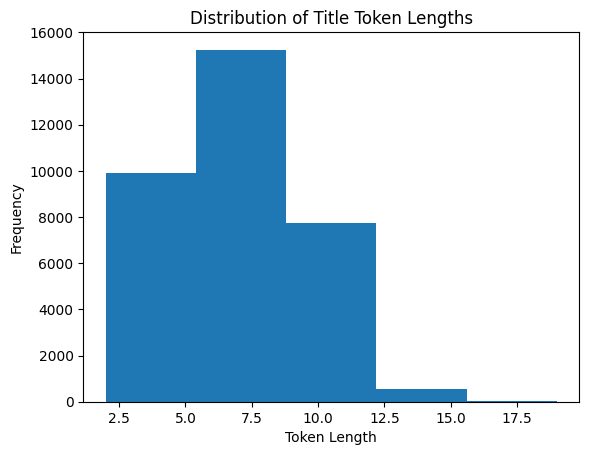

In [33]:
plt.hist([len(token) for token in title_tokens], bins=5)
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.title('Distribution of Title Token Lengths')
plt.show()  

In [34]:
title_counter = CountVectorizer(lowercase=False)
title_counts = title_counter.fit_transform(ag_news.title)

In [35]:
len(title_counter.vocabulary_)

47912

In [36]:
ag_news.sample(20, random_state=42)

,label,title,description
71787,3,"BBC set for major shake-up, claims newspaper","London - The British Broadcasting Corporation,..."
67218,3,Marsh averts cash crunch,Embattled insurance broker #39;s banks agree t...
54066,2,"Jeter, Yankees Look to Take Control (AP)",AP - Derek Jeter turned a season that started ...
7168,4,Flying the Sun to Safety,When the Genesis capsule comes back to Earth w...
29618,3,Stocks Seen Flat as Nortel and Oil Weigh,NEW YORK (Reuters) - U.S. stocks were set to ...
101425,2,Inter Milan seeks redemption win against Juventus,It is early in the season for a decisive match...
20441,3,Saudi Arabia cuts oil prices,Oil prices eased yesterday as top world export...
2662,1,Google Cuts Its IPO Price Range,"SAN JOSE, Calif. - In a sign that Google Inc.'..."
20371,3,FOCUS: Santander Says HBOS Counterbid To Face ...,LONDON (Dow Jones)--Banco Santander Central Hi...
108151,4,HP Revises Cluster Plans,"HP (Quote, Chart) is dropping its efforts to p..."


### Problem 3. Types of tokens
Take a small but diverse sample of texts and compare at least two tokenization strategies. Include examples with punctuation ("e-commerce", "doesn't", possessives), abbreviations ("U.S.", "IBM"), numbers ("20%", "3.5M USD", "11 March"), and hyphenated expressions ("wishy-washy"). Show where naive splitting fails and what your improved strategy fixes.

You might want to iterate on this several times until you arrive at an acceptable strategy.

Also try n-grams, even though they will increase the vocabulary size by. a lot.

In [ ]:
SAMPLES_PER_CLASS = 25
all_samples = []

for label, group_data in ag_news.groupby('label'):
    selected_news = group_data[
    (group_data.title.str.len() >= 20) &
    (group_data.title.str.len() <= 60) &
    (group_data.description.str.len() >= 150) &
    (group_data.description.str.len() <= 250)
   ]
    print(len(selected_news), f'news items in label {label}')
    selected_news = selected_news.sample(SAMPLES_PER_CLASS, random_state=42)
    all_samples.append(selected_news)

In [41]:
all_samples = pd.concat(all_samples)

In [42]:
all_samples

,label,title,description
40230,1,Resistant Israeli Settlers May Get Prison (AP),AP - Armed settlers who resist evacuation coul...
55666,1,21 Killed in Fresh Iraq Violence,"BAGHDAD, 6 December 2004 - Seventeen civilians..."
100976,1,Northern Italy Struck By 5.3 Magnitude Earthqu...,A 5.3-magnitude earthquake struck Northern Ita...
1033,1,Iraq Conference in Najaf Peace Bid; Oil Well A...,BAGHDAD (Reuters) - U.S. troops and Shi'ite m...
71496,1,Failure of Gaza pullout plan would be catastro...,JERUSALEM - Opposition leader Shimon Peres war...
...,...,...,...
39875,4,Red Hat vs Sun Battle of Words Heats Up,"quot;When the elephants fight, quot; they say..."
830,4,Symantec releases patching tool,Security company Symantec Corp. plans to annou...
63586,4,Micron planning its first factory in China,Micron Technology Inc. is currently in the pro...
59864,4,"Visa Issues Vex Tech Workers, Their Employers",Dawn M. Lurie knows how to wake up her audienc...


In [43]:
all_samples.to_csv('data/sample_ag_news.csv', index=None)

In [44]:
all_samples.iloc[84]

label                                                          4
title                                 Cisco routers add services
description    Cisco Systems this week will introduce a new l...
Name: 25933, dtype: object

In [48]:
ag_news[ag_news.description.str.startswith('')]

,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
...,...,...,...
119995,1,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...
119996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...
119997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...
119998,2,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...


In [50]:
ag_news[ag_news.description.str.contains('#36;', regex=True)].description.values

<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           'Reuters - Stocks ended slightly higher on Friday\but stayed near lows for the year as oil prices surged past  #36;46\a barrel, offsetting a positive outlook from computer maker\Dell Inc. (DELL.O)',
                                                                                                                                                       

In [47]:
ag_news[ag_news.description.str.startswith('')].description.values

<StringArray>
[                                                                                                                                                                                                                                                                                                        'Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.',
                                                                                                                                                                                 'Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.',
                                                                                                                                                                                                    

In [51]:
ag_news.description.replace('#36;', '$', regex=True)

0         Reuters - Short-sellers, Wall Street's dwindli...
1         Reuters - Private investment firm Carlyle Grou...
2         Reuters - Soaring crude prices plus worries\ab...
3         Reuters - Authorities have halted oil export\f...
4         AFP - Tearaway world oil prices, toppling reco...
                                ...                        
119995     KARACHI (Reuters) - Pakistani President Perve...
119996    Red Sox general manager Theo Epstein acknowled...
119997    The Miami Dolphins will put their courtship of...
119998    PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...
119999    INDIANAPOLIS -- All-Star Vince Carter was trad...
Name: description, Length: 120000, dtype: str

In [53]:
ag_news.description.str.contains('#\\d{2}', regex=True)

0         False
1         False
2         False
3         False
4         False
          ...  
119995    False
119996    False
119997    False
119998    False
119999    False
Name: description, Length: 120000, dtype: bool

In [54]:
ag_news.description = ag_news.description.replace('#36;', '$', regex=True)
ag_news.title = ag_news.title.replace('#36;', '$', regex=True)

In [55]:
ag_news.description = ag_news.description.replace('#39;', "'", regex=True)
ag_news.title = ag_news.title.replace('#39;', "'", regex=True)

In [56]:
ag_news.description = ag_news.description.replace('#38;', '&', regex=True)
ag_news.title = ag_news.title.replace('#38;', '&', regex=True)

In [57]:
ag_news.description = ag_news.description.replace('#37;', '%', regex=True)
ag_news.title = ag_news.title.replace('#37;', '%', regex=True)

In [58]:
ag_news = ag_news.drop(45934)

In [59]:
ag_news[ag_news.title.str.contains(" -- ")]

,label,title,description
478,2,'Gardening' costs Appleby -- in spades,"HAVEN, Wis. -- For 18 holes, Stuart Appleby pl..."
1065,4,Exercise -- the Real Fountain of Youth,Want to age gracefully? Keep moving. Regular e...
1105,4,"Sidebar: The nuts and bolts of COM -- Objects,...",A quick course in how some of the most esoteri...
2174,2,Event of the Day -- Men 's and women 's shot put,Why you should watch: Given the longstanding A...
3246,4,Half of US Web Users Now on Broadband -- Report,NEW YORK (Reuters) - More than half of all US ...
...,...,...,...
117854,1,"World Racked by Political, Social 'Evil' -- Pope",VATICAN CITY (Reuters) - Social and political...
117883,1,"Bin Laden Alive, Releases Audio Tape -- Web Site",An audio recording purportedly by Osama bin La...
118261,2,Ole Miss Contacts Erickson -- 'It 's Somethin...,Don 't count San Francisco 49ers coach Dennis ...
118926,3,Court Seen Lifting YUKOS Block -- Lawyers (Reu...,Reuters - A U.S. bankruptcy court is likely to...


In [60]:
selected_news[selected_news.description.str.contains(" \n")]

,label,title,description


In [62]:
selected_news[selected_news.description.str.contains("\\$")].description.values

<StringArray>
['U.K. semiconductor design company Arm Holdings PLC has agreed to acquire a Sunnyvale, California, provider of components for chip manufacturing in a deal valued at around \$913 million in cash and stock.']
Length: 1, dtype: str

In [63]:
ag_news.description.str.replace("\d+", "<digits>")

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\PC\AppData\Local\Temp\ipykernel_19520\4114133429.py:1: SyntaxWarning: invalid escape sequence '\d'
  ag_news.description.str.replace("\d+", "<digits>")


0         Reuters - Short-sellers, Wall Street's dwindli...
1         Reuters - Private investment firm Carlyle Grou...
2         Reuters - Soaring crude prices plus worries\ab...
3         Reuters - Authorities have halted oil export\f...
4         AFP - Tearaway world oil prices, toppling reco...
                                ...                        
119995     KARACHI (Reuters) - Pakistani President Perve...
119996    Red Sox general manager Theo Epstein acknowled...
119997    The Miami Dolphins will put their courtship of...
119998    PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...
119999    INDIANAPOLIS -- All-Star Vince Carter was trad...
Name: description, Length: 119999, dtype: str

In [64]:
description_without_digits = ag_news.description.str.replace("\d+", "<digits>")

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\PC\AppData\Local\Temp\ipykernel_19520\665966479.py:1: SyntaxWarning: invalid escape sequence '\d'
  description_without_digits = ag_news.description.str.replace("\d+", "<digits>")


In [65]:
description_without_digits[description_without_digits.str.contains("<digits>")].values

<StringArray>
[]
Length: 0, dtype: str

### Problem 4. Normalization
Compare several normalization choices on the same subset of data: lowercasing, stopword removal, stemming, and lemmatization. Show how the vocabulary changes and discuss which distinctions were useful to remove and which may have been worth keeping.

Some ideas to compare:
* raw vs. normalized vocabulary size
* some example token transformations
* stemmed vs lemmatized terms that look good or bad
* \* ideas on how to keep named entities / proper nouns

In [ ]:
# Write your code here

### Problem 5. A better EDA
You should have alerady done some statistics in the previous problems. Now, compute and visualize something interesting about the dataset, that you didn't know (or maybe even expect) beforehand. Avoid filler.

You can focus on edge cases, special tokens / words / n-grams / terms / titles, anomalies, named entities, vocabulary size and sparsity, any considerations for a classification model, etc. These are just my ides; it's up to you to design your EDA. You may want to pay even more special attention to titles vs. descriptions; especially if you would like to only use one of them.

You can allow your EDA to modify your text processing pipeline from above. The goal is to arrive at a good way to both _understand_ the news (in your head) and _extract features_ for modelling.

In [67]:
title_counter = CountVectorizer()
title_counts = title_counter.fit_transform(ag_news.title)

title_counter_ngrams = CountVectorizer(ngram_range=(1, 5))
title_counts_ngrams = title_counter_ngrams.fit_transform(ag_news.title)

title_counts.shape, title_counts_ngrams.shape

((119999, 33495), (119999, 1520822))

### Problem 6. Bag of Words
The title should be self-explanatory. Once you've settled in on a text processing pipeline, run a BoW (`CountVectorizer`). Show what rows and columns mean, how sparse the result is, and which kinds of words become prominent. Compare **at least two** reasonable vectorizer settings (hyperparameters).

In [ ]:
# Write your code here

### Problem 7. Naïve Bayes
Train a Naïve Bayes classifier (`MultinomialNB`) on a count-based representation of the corpus. Your target is the `Label` column; it's a 4-class classification task.

Compare at least two text/preprocessing setups and inspect not only the overall score but also the kinds of mistakes the model makes.

You might want to start using the `test.jsonl` file now. But don't worry if you can't or don't want to - training and testing on the whole dataset is kind of okay for now. We'll talk about ML later (although you should already know enough about evaluating a model based on your hypothesis testing knowledge).

In [68]:
bayes = MultinomialNB()
bayes.fit(title_counts, ag_news.label)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [69]:
bayes.score(title_counts, ag_news.label)

0.891649097075809

In [70]:
bayes_ngrams = MultinomialNB()
bayes_ngrams.fit(title_counts_ngrams, ag_news.label)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [71]:
bayes_ngrams.score(title_counts_ngrams, ag_news.label)

0.9753414611788431

In [73]:
classification_report(ag_news.label, bayes.predict(title_counts))

'              precision    recall  f1-score   support\n\n           1       0.90      0.89      0.90     30000\n           2       0.92      0.95      0.94     30000\n           3       0.87      0.86      0.86     30000\n           4       0.87      0.87      0.87     29999\n\n    accuracy                           0.89    119999\n   macro avg       0.89      0.89      0.89    119999\nweighted avg       0.89      0.89      0.89    119999\n'

In [74]:
print(classification_report(ag_news.label, bayes_ngrams.predict(title_counts_ngrams)))

              precision    recall  f1-score   support

           1       0.99      0.96      0.97     30000
           2       0.98      0.99      0.99     30000
           3       0.97      0.97      0.97     30000
           4       0.97      0.98      0.97     29999

    accuracy                           0.98    119999
   macro avg       0.98      0.98      0.98    119999
weighted avg       0.98      0.98      0.98    119999



In [75]:
title_counter_truncated = CountVectorizer(min_df=10, max_df=0.5)
title_counts_truncated = title_counter_truncated.fit_transform(ag_news.title)

In [76]:
bayes_truncated = MultinomialNB()
bayes_truncated.fit(title_counts_truncated, ag_news.label)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [78]:
print(classification_report(ag_news.label, bayes_truncated.predict(title_counts_truncated)))

              precision    recall  f1-score   support

           1       0.88      0.87      0.87     30000
           2       0.90      0.93      0.91     30000
           3       0.85      0.82      0.84     30000
           4       0.84      0.85      0.84     29999

    accuracy                           0.87    119999
   macro avg       0.87      0.87      0.87    119999
weighted avg       0.87      0.87      0.87    119999



In [81]:
PCA(title_counter_truncated)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1","CountVectoriz....5, min_df=10)"
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration

In [82]:
PCA(n_components=50)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",50
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

In [83]:
pca = PCA(n_components=50)

In [85]:
pca.fit(title_counts_truncated)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",50
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

### * Problem 8. TF-IDF
Redo the operations from the last two problems using TF-IDF. Compare **at least three** settings. Rerun the NB classifier, possibly with different settings.

Show what kinds of terms become more prominent, how nearest neighbors change, and whether classification improves or just starts being wrong in a different way.

In [ ]:
# Write your code here

### Problrm 9. Similarities and retrieval
Given an article, retrieve similar articles using at least two different feature/similarity combinations. Show successful retrievals and obviously wrong ones. Explain what you mean by "similar".

A very, very simple starting point is to compare titles. Think about how to obtain vectors (are BoW / TF-IDF enough?) and what distance metrics to use.

Think how to use the results to reduce the number of articles for modelling if you think they don't provide much value.

In [ ]:
# Write your code here

### * Problem 10. Clustering / topic modelling
Perform one (or both) of the tasks to understand what people are _really_ talking about. For example, there might be several clusters within one label, or a cluster may include multiple labels.

For clustering, you might want to use `k-means` or `DBSCAN` (if you suspect a significant amount of outliers).

For topic modelling, you might want to use `NMF`, `Latent Dirichlet Allocation`, or even TF-IDF features. You may even go deeper by using a more ML-oriented approach, such as an isolation forest.

In [ ]:
# Write your code here

### * Problem 11. Deep features
Choose one task - retrieval / classification / clustering / topic modelling. Compare your feature extraction pipeline for this task to **at least one** language / embedding / feature extraction model. In order to create a better (quantifiable) comparison, you may use "downstream" models; e.g., for classification you can compare your vectors vs. a deep embedding model.

Some models you might want to try are `Word2Vec`, `GloVe`, `sentence-transformers` (it's a library), or `HuggingFace transformers` (also a library; there's a "Models" section in their website).

**Note:** You'll likely need a good machine (or a cloud resource) for this task.

In [ ]:
# Write your code here